In [4]:
import os
import sys
import numpy as np
import pandas as pd

print("Python:", sys.version)
print("Working directory:", os.getcwd())
print("Pandas version:", pd.__version__)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Working directory: D:\AI_Disaster_Prediction_Blockchain_Fund_Allocation\AI_Disaster_Prediction_Blockchain_Fund_Allocation\ml_training\cyclone\notebooks
Pandas version: 2.2.3


In [5]:
DATA_PATH = "../data/processed/cyclone_processed.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset loaded successfully!
Rows: 7488
Columns: 18

Columns:
['SID', 'SEASON', 'NAME', 'ISO_TIME', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'STORM_SPEED', 'STORM_DIR', 'DIST2LAND', 'previous_wind', 'wind_change', 'year', 'month', 'day', 'hour', 'intensifies']


,SID,SEASON,NAME,ISO_TIME,LAT,LON,WMO_WIND,WMO_PRES,STORM_SPEED,STORM_DIR,DIST2LAND,previous_wind,wind_change,year,month,day,hour,intensifies
0,1932244N19296,1932,UNNAMED,1932-08-30 18:00:00+00:00,18.8,-63.6,30.0,995.0,9.0,305.0,215,35.0,0.0,1932,8,30,18,0
1,1932244N19296,1932,UNNAMED,1932-08-31 00:00:00+00:00,19.3,-64.4,30.0,995.0,9.0,305.0,161,30.0,0.0,1932,8,31,0,1
2,1932244N19296,1932,UNNAMED,1932-08-31 06:00:00+00:00,19.8,-65.2,35.0,995.0,9.0,300.0,162,30.0,5.0,1932,8,31,6,1
3,1932244N19296,1932,UNNAMED,1932-08-31 12:00:00+00:00,20.2,-66.0,40.0,995.0,7.0,295.0,201,35.0,5.0,1932,8,31,12,1
4,1932244N19296,1932,UNNAMED,1932-08-31 18:00:00+00:00,20.4,-66.6,45.0,995.0,5.0,290.0,223,40.0,5.0,1932,8,31,18,1


In [6]:
print("Target distribution:")
print(df["intensifies"].value_counts())

print("\nTarget percentage:")
print(df["intensifies"].value_counts(normalize=True).mul(100).round(2))

Target distribution:
intensifies
0    6144
1    1344
Name: count, dtype: int64

Target percentage:
intensifies
0    82.05
1    17.95
Name: proportion, dtype: float64


In [7]:
print("Number of unique cyclones:", df["SID"].nunique())

print("\nRows per cyclone:")
print(df.groupby("SID").size().describe())

Number of unique cyclones: 436

Rows per cyclone:
count    436.000000
mean      17.174312
std       15.062685
min        1.000000
25%        6.000000
50%       13.000000
75%       23.250000
max       96.000000
dtype: float64


In [8]:
features = [
    "LAT",
    "LON",
    "WMO_WIND",
    "WMO_PRES",
    "STORM_SPEED",
    "STORM_DIR",
    "DIST2LAND",
    "previous_wind",
    "wind_change"
]

print(df[features].describe().T)

                count        mean         std    min    25%    50%     75%  \
LAT            7488.0   16.550654    6.541567    1.5   12.4   16.0    20.2   
LON            7488.0   77.982732   27.953047  -87.7   69.2   83.7    88.2   
WMO_WIND       7488.0   42.313301   22.163311    3.0   25.0   35.0    50.0   
WMO_PRES       7488.0  991.173344   14.184944  890.0  988.0  995.0  1000.0   
STORM_SPEED    7488.0    7.777644    5.002107    0.0    5.0    7.0    10.0   
STORM_DIR      7488.0  220.920139  119.867926    0.0   75.0  275.0   305.0   
DIST2LAND      7488.0  296.769899  283.239252    0.0   49.0  243.0   482.0   
previous_wind  7488.0   42.513889   21.712525    3.0   25.0   35.0    50.0   
wind_change    7488.0    0.346554    4.654451  -97.0    0.0    0.0     0.0   

                  max  
LAT              79.5  
LON             143.6  
WMO_WIND        140.0  
WMO_PRES       1011.0  
STORM_SPEED      54.0  
STORM_DIR       360.0  
DIST2LAND      2270.0  
previous_wind   140.0  
win

Target distribution:
intensifies
0    6144
1    1344
Name: count, dtype: int64

Target percentage:
intensifies
0    82.05
1    17.95
Name: proportion, dtype: float64


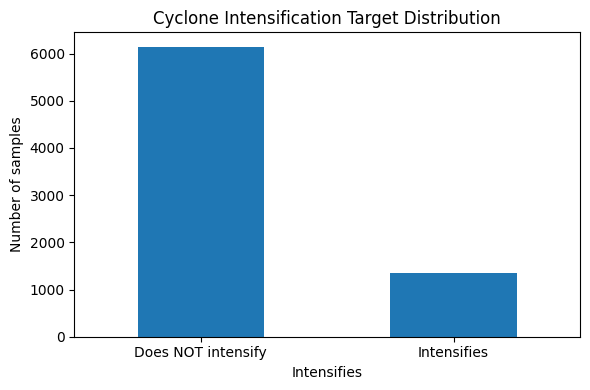

In [9]:
import matplotlib.pyplot as plt

print("Target distribution:")
print(df["intensifies"].value_counts())

print("\nTarget percentage:")
print(df["intensifies"].value_counts(normalize=True).mul(100).round(2))

df["intensifies"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Cyclone Intensification Target Distribution")
plt.xlabel("Intensifies")
plt.ylabel("Number of samples")
plt.xticks([0, 1], ["Does NOT intensify", "Intensifies"], rotation=0)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# Get unique cyclone IDs
cyclone_ids = df["SID"].unique()

print("Total unique cyclones:", len(cyclone_ids))

# 70% train, 15% validation, 15% test
train_ids, temp_ids = train_test_split(
    cyclone_ids,
    test_size=0.30,
    random_state=42
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42
)

# Create datasets using cyclone IDs
train_df = df[df["SID"].isin(train_ids)].copy()
val_df = df[df["SID"].isin(val_ids)].copy()
test_df = df[df["SID"].isin(test_ids)].copy()

print("\nDataset split:")
print("Train cyclones:", len(train_ids))
print("Validation cyclones:", len(val_ids))
print("Test cyclones:", len(test_ids))

print("\nRows:")
print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

print("\nTarget distribution:")
print("Train:")
print(train_df["intensifies"].value_counts())

print("\nValidation:")
print(val_df["intensifies"].value_counts())

print("\nTest:")
print(test_df["intensifies"].value_counts())

Total unique cyclones: 436

Dataset split:
Train cyclones: 305
Validation cyclones: 65
Test cyclones: 66

Rows:
Train rows: 5300
Validation rows: 1124
Test rows: 1064

Target distribution:
Train:
intensifies
0    4379
1     921
Name: count, dtype: int64

Validation:
intensifies
0    918
1    206
Name: count, dtype: int64

Test:
intensifies
0    847
1    217
Name: count, dtype: int64


In [12]:
FEATURES = [
    "LAT",
    "LON",
    "WMO_WIND",
    "WMO_PRES",
    "STORM_SPEED",
    "STORM_DIR",
    "DIST2LAND",
    "previous_wind",
    "wind_change",
    "year",
    "month",
    "day",
    "hour"
]

TARGET = "intensifies"

X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()

X_val = val_df[FEATURES].copy()
y_val = val_df[TARGET].copy()

X_test = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

print("Feature preparation completed.")
print("Number of features:", len(FEATURES))

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFeatures:")
for feature in FEATURES:
    print("-", feature)

Feature preparation completed.
Number of features: 13

X_train: (5300, 13)
y_train: (5300,)
X_val: (1124, 13)
y_val: (1124,)
X_test: (1064, 13)
y_test: (1064,)

Features:
- LAT
- LON
- WMO_WIND
- WMO_PRES
- STORM_SPEED
- STORM_DIR
- DIST2LAND
- previous_wind
- wind_change
- year
- month
- day
- hour


In [15]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Feature scaling completed.
X_train_scaled: (5300, 13)
X_val_scaled: (1124, 13)
X_test_scaled: (1064, 13)


In [16]:
# ============================================================
# Create 12-time-step sequences
# ============================================================

import numpy as np

SEQUENCE_LENGTH = 12

def create_sequences(X, y, sequence_length=12):
    X_seq = []
    y_seq = []

    for i in range(len(X) - sequence_length + 1):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(y[i + sequence_length - 1])

    return np.array(X_seq), np.array(y_seq)


X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train.to_numpy(),
    SEQUENCE_LENGTH
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val.to_numpy(),
    SEQUENCE_LENGTH
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test.to_numpy(),
    SEQUENCE_LENGTH
)

print("Sequence creation completed.")
print()
print("Sequence length:", SEQUENCE_LENGTH)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_val_seq:", X_val_seq.shape)
print("y_val_seq:", y_val_seq.shape)

print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

Sequence creation completed.

Sequence length: 12
X_train_seq: (5289, 12, 13)
y_train_seq: (5289,)
X_val_seq: (1113, 12, 13)
y_val_seq: (1113,)
X_test_seq: (1053, 12, 13)
y_test_seq: (1053,)


In [18]:
# ============================================================
# Define model features
# ============================================================

feature_columns = [
    "LAT",
    "LON",
    "WMO_WIND",
    "WMO_PRES",
    "STORM_SPEED",
    "STORM_DIR",
    "DIST2LAND",
    "previous_wind",
    "wind_change",
    "year",
    "month",
    "day",
    "hour"
]

print("Features defined successfully.")
print("Number of features:", len(feature_columns))
print(feature_columns)

Features defined successfully.
Number of features: 13
['LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'STORM_SPEED', 'STORM_DIR', 'DIST2LAND', 'previous_wind', 'wind_change', 'year', 'month', 'day', 'hour']


In [19]:
# ============================================================
# Create sequences separately for each cyclone
# ============================================================

SEQUENCE_LENGTH = 12

def create_cyclone_sequences(df_split, feature_columns, sequence_length=12):
    X_sequences = []
    y_sequences = []

    for sid, group in df_split.groupby("SID"):

        group = group.sort_values("ISO_TIME")

        X = group[feature_columns].values
        y = group["intensifies"].values

        if len(group) < sequence_length:
            continue

        for i in range(len(group) - sequence_length + 1):
            X_sequences.append(
                X[i:i + sequence_length]
            )
            y_sequences.append(
                y[i + sequence_length - 1]
            )

    return np.array(X_sequences), np.array(y_sequences)


X_train_seq, y_train_seq = create_cyclone_sequences(
    train_df,
    feature_columns,
    SEQUENCE_LENGTH
)

X_val_seq, y_val_seq = create_cyclone_sequences(
    val_df,
    feature_columns,
    SEQUENCE_LENGTH
)

X_test_seq, y_test_seq = create_cyclone_sequences(
    test_df,
    feature_columns,
    SEQUENCE_LENGTH
)

print("Cyclone-by-cyclone sequence creation completed.")
print()

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_val_seq:", X_val_seq.shape)
print("y_val_seq:", y_val_seq.shape)

print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

print()
print("Training target distribution:")
print(pd.Series(y_train_seq).value_counts().sort_index())

print()
print("Validation target distribution:")
print(pd.Series(y_val_seq).value_counts().sort_index())

print()
print("Test target distribution:")
print(pd.Series(y_test_seq).value_counts().sort_index())

Cyclone-by-cyclone sequence creation completed.

X_train_seq: (2663, 12, 13)
y_train_seq: (2663,)
X_val_seq: (576, 12, 13)
y_val_seq: (576,)
X_test_seq: (505, 12, 13)
y_test_seq: (505,)

Training target distribution:
0    2325
1     338
Name: count, dtype: int64

Validation target distribution:
0    496
1     80
Name: count, dtype: int64

Test target distribution:
0    438
1     67
Name: count, dtype: int64


In [20]:
# ============================================================
# Apply SMOTE to training sequences
# ============================================================

from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("\nClass distribution before SMOTE:")
print(pd.Series(y_train_seq).value_counts().sort_index())

# ------------------------------------------------------------
# Flatten each sequence
# SMOTE works with 2D data
# ------------------------------------------------------------

n_samples = X_train_seq.shape[0]
sequence_length = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]

X_train_flat = X_train_seq.reshape(
    n_samples,
    sequence_length * n_features
)

# ------------------------------------------------------------
# Apply SMOTE
# ------------------------------------------------------------

smote = SMOTE(
    random_state=42
)

X_train_flat_smote, y_train_smote = smote.fit_resample(
    X_train_flat,
    y_train_seq
)

# ------------------------------------------------------------
# Reshape back to sequence format
# ------------------------------------------------------------

X_train_smote = X_train_flat_smote.reshape(
    -1,
    sequence_length,
    n_features
)

print("\nAfter SMOTE:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

Before SMOTE:
X_train_seq: (2663, 12, 13)
y_train_seq: (2663,)

Class distribution before SMOTE:
0    2325
1     338
Name: count, dtype: int64

After SMOTE:
X_train_smote: (4650, 12, 13)
y_train_smote: (4650,)

Class distribution after SMOTE:
0    2325
1    2325
Name: count, dtype: int64


In [21]:
# ============================================================
# Baseline LSTM Model
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Building Baseline LSTM...")

baseline_lstm = Sequential([
    Input(shape=(SEQUENCE_LENGTH, len(feature_columns))),

    LSTM(32),

    Dense(16, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

baseline_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_lstm.summary()

Building Baseline LSTM...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           5,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,433 (25.13 KB)

 Trainable params: 6,433 (25.13 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# ============================================================
# Train Baseline LSTM
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Training Baseline LSTM...")

history_lstm = baseline_lstm.fit(
    X_train_smote,
    y_train_smote,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\nBaseline LSTM training completed.")

Training Baseline LSTM...
Epoch 1/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5196 - loss: 0.6933 - val_accuracy: 0.6701 - val_loss: 0.6712
Epoch 2/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6022 - loss: 0.6789 - val_accuracy: 0.7899 - val_loss: 0.6420
Epoch 3/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6206 - loss: 0.6723 - val_accuracy: 0.6736 - val_loss: 0.6665
Epoch 4/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6032 - loss: 0.6703 - val_accuracy: 0.8003 - val_loss: 0.6570
Epoch 5/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5953 - loss: 0.6704 - val_accuracy: 0.6840 - val_loss: 0.6444
Epoch 6/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6176 - loss: 0.6651 - val_accuracy: 0.5087 - val_loss: 0.7080
Epoch 7/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6245 - loss: 0.6633 - val_accuracy: 0.7622 - val_loss: 0.6061
Epoch 8/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6357

In [23]:
# ============================================================
# Baseline LSTM Predictions and Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("Generating Baseline LSTM predictions...")

lstm_prob = baseline_lstm.predict(
    X_test_seq,
    verbose=0
).ravel()

lstm_pred = (lstm_prob >= 0.5).astype(int)

lstm_accuracy = accuracy_score(y_test_seq, lstm_pred)
lstm_precision = precision_score(
    y_test_seq,
    lstm_pred,
    zero_division=0
)
lstm_recall = recall_score(
    y_test_seq,
    lstm_pred,
    zero_division=0
)
lstm_f1 = f1_score(
    y_test_seq,
    lstm_pred,
    zero_division=0
)
lstm_roc_auc = roc_auc_score(
    y_test_seq,
    lstm_prob
)
lstm_pr_auc = average_precision_score(
    y_test_seq,
    lstm_prob
)

print("\n=== Baseline LSTM Results ===")
print(f"Accuracy : {lstm_accuracy:.4f}")
print(f"Precision: {lstm_precision:.4f}")
print(f"Recall   : {lstm_recall:.4f}")
print(f"F1       : {lstm_f1:.4f}")
print(f"ROC-AUC  : {lstm_roc_auc:.4f}")
print(f"PR-AUC   : {lstm_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_seq, lstm_pred))

Generating Baseline LSTM predictions...

=== Baseline LSTM Results ===
Accuracy : 0.7267
Precision: 0.2290
Recall   : 0.4478
F1       : 0.3030
ROC-AUC  : 0.6911
PR-AUC   : 0.2509

Confusion Matrix:
[[337 101]
 [ 37  30]]


In [24]:
# ============================================================
# Save Baseline LSTM Model and Predictions
# ============================================================

import os

os.makedirs("models", exist_ok=True)
os.makedirs("predictions", exist_ok=True)
os.makedirs("results", exist_ok=True)

baseline_lstm.save(
    "models/cyclone_baseline_lstm_notebook.keras"
)

np.savez(
    "predictions/baseline_lstm_notebook_predictions.npz",
    y_test=y_test_seq,
    y_pred_proba=lstm_prob
)

with open(
    "results/baseline_lstm_notebook_results.txt",
    "w"
) as f:

    f.write("=== Baseline LSTM Results ===\n")
    f.write(f"Accuracy : {lstm_accuracy:.4f}\n")
    f.write(f"Precision: {lstm_precision:.4f}\n")
    f.write(f"Recall   : {lstm_recall:.4f}\n")
    f.write(f"F1       : {lstm_f1:.4f}\n")
    f.write(f"ROC-AUC  : {lstm_roc_auc:.4f}\n")
    f.write(f"PR-AUC   : {lstm_pr_auc:.4f}\n")

print("\nSaved:")
print("models/cyclone_baseline_lstm_notebook.keras")
print("predictions/baseline_lstm_notebook_predictions.npz")
print("results/baseline_lstm_notebook_results.txt")


Saved:
models/cyclone_baseline_lstm_notebook.keras
predictions/baseline_lstm_notebook_predictions.npz
results/baseline_lstm_notebook_results.txt


In [25]:
# ============================================================
# Baseline LSTM Model
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Building Baseline LSTM...")

baseline_lstm = Sequential([
    Input(shape=(SEQUENCE_LENGTH, len(feature_columns))),
    LSTM(32),
    Dense(16, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

baseline_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_lstm.summary()

Building Baseline LSTM...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 32)                  │           5,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,433 (25.13 KB)

 Trainable params: 6,433 (25.13 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ============================================================
# Train Baseline LSTM
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Training Baseline LSTM...")

history_lstm = baseline_lstm.fit(
    X_train_smote,
    y_train_smote,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\nBaseline LSTM training completed.")

Training Baseline LSTM...
Epoch 1/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5065 - loss: 0.6983 - val_accuracy: 0.1510 - val_loss: 0.6989
Epoch 2/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5252 - loss: 0.6899 - val_accuracy: 0.5486 - val_loss: 0.6785
Epoch 3/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5697 - loss: 0.6818 - val_accuracy: 0.5122 - val_loss: 0.6527
Epoch 4/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6000 - loss: 0.6710 - val_accuracy: 0.3576 - val_loss: 0.6879
Epoch 5/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6155 - loss: 0.6633 - val_accuracy: 0.5660 - val_loss: 0.6438
Epoch 6/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6099 - loss: 0.6642 - val_accuracy: 0.6024 - val_loss: 0.6464
Epoch 7/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6320 - loss: 0.6595 - val_accuracy: 0.3646 - val_loss: 0.6978
Epoch 8/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6256

In [27]:
# ============================================================
# Baseline LSTM Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Generating Baseline LSTM test predictions...")

y_lstm_prob = baseline_lstm.predict(
    X_test_seq,
    verbose=0
).ravel()

y_lstm_pred = (y_lstm_prob >= 0.5).astype(int)

lstm_accuracy = accuracy_score(y_test_seq, y_lstm_pred)
lstm_precision = precision_score(y_test_seq, y_lstm_pred, zero_division=0)
lstm_recall = recall_score(y_test_seq, y_lstm_pred, zero_division=0)
lstm_f1 = f1_score(y_test_seq, y_lstm_pred, zero_division=0)
lstm_roc_auc = roc_auc_score(y_test_seq, y_lstm_prob)
lstm_pr_auc = average_precision_score(y_test_seq, y_lstm_prob)

print("\n=== Baseline LSTM Results ===")
print(f"Accuracy : {lstm_accuracy:.4f}")
print(f"Precision: {lstm_precision:.4f}")
print(f"Recall   : {lstm_recall:.4f}")
print(f"F1       : {lstm_f1:.4f}")
print(f"ROC-AUC  : {lstm_roc_auc:.4f}")
print(f"PR-AUC   : {lstm_pr_auc:.4f}")

Generating Baseline LSTM test predictions...

=== Baseline LSTM Results ===
Accuracy : 0.6139
Precision: 0.2091
Recall   : 0.6866
F1       : 0.3206
ROC-AUC  : 0.6780
PR-AUC   : 0.1983


In [28]:
# ============================================================
# Save Baseline LSTM Model, Predictions and Results
# ============================================================

import os
import numpy as np

os.makedirs("models", exist_ok=True)
os.makedirs("predictions", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Save trained model
baseline_lstm.save(
    "models/cyclone_baseline_lstm_notebook.keras"
)

# Save predictions
np.savez(
    "predictions/baseline_lstm_notebook_predictions.npz",
    y_test=y_test_seq,
    y_pred_proba=y_lstm_prob
)

# Save metrics
with open(
    "results/baseline_lstm_notebook_results.txt",
    "w"
) as f:
    f.write("=== Baseline LSTM Results ===\n")
    f.write(f"Accuracy : {lstm_accuracy:.4f}\n")
    f.write(f"Precision: {lstm_precision:.4f}\n")
    f.write(f"Recall   : {lstm_recall:.4f}\n")
    f.write(f"F1       : {lstm_f1:.4f}\n")
    f.write(f"ROC-AUC  : {lstm_roc_auc:.4f}\n")
    f.write(f"PR-AUC   : {lstm_pr_auc:.4f}\n")

print("Baseline LSTM saved successfully.")
print()
print("Model:")
print("models/cyclone_baseline_lstm_notebook.keras")
print()
print("Predictions:")
print("predictions/baseline_lstm_notebook_predictions.npz")
print()
print("Results:")
print("results/baseline_lstm_notebook_results.txt")

Baseline LSTM saved successfully.

Model:
models/cyclone_baseline_lstm_notebook.keras

Predictions:
predictions/baseline_lstm_notebook_predictions.npz

Results:
results/baseline_lstm_notebook_results.txt


In [29]:
# ============================================================
# CNN-LSTM Model
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

print("Building CNN-LSTM...")

cnn_lstm = Sequential([
    Input(shape=(SEQUENCE_LENGTH, len(feature_columns))),

    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    MaxPooling1D(pool_size=2),

    LSTM(32),

    Dense(16, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

cnn_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_lstm.summary()

Building CNN-LSTM...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 12, 32)              │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 6, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,145 (39.63 KB)

 Trainable params: 10,145 (39.63 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# ============================================================
# Train CNN-LSTM
# ============================================================

early_stopping_cnn = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Training CNN-LSTM...")

history_cnn_lstm = cnn_lstm.fit(
    X_train_smote,
    y_train_smote,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping_cnn],
    verbose=1
)

print("\nCNN-LSTM training completed.")

Training CNN-LSTM...
Epoch 1/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5398 - loss: 0.6897 - val_accuracy: 0.1493 - val_loss: 0.7722
Epoch 2/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5361 - loss: 0.6899 - val_accuracy: 0.8542 - val_loss: 0.6582
Epoch 3/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5153 - loss: 0.6944 - val_accuracy: 0.3455 - val_loss: 0.7004
Epoch 4/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5056 - loss: 0.6974 - val_accuracy: 0.6910 - val_loss: 0.6893
Epoch 5/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5338 - loss: 0.6914 - val_accuracy: 0.5208 - val_loss: 0.7071
Epoch 6/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5331 - loss: 0.6907 - val_accuracy: 0.4670 - val_loss: 0.6947
Epoch 7/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5624 - loss: 0.6869 - val_accuracy: 0.1389 - val_loss: 0.7356

CNN-LSTM training completed.


In [31]:
# ============================================================
# CNN-LSTM Evaluation
# ============================================================

print("Generating CNN-LSTM test predictions...")

y_cnn_prob = cnn_lstm.predict(
    X_test_seq,
    verbose=0
).ravel()

y_cnn_pred = (y_cnn_prob >= 0.5).astype(int)

cnn_accuracy = accuracy_score(y_test_seq, y_cnn_pred)
cnn_precision = precision_score(y_test_seq, y_cnn_pred, zero_division=0)
cnn_recall = recall_score(y_test_seq, y_cnn_pred, zero_division=0)
cnn_f1 = f1_score(y_test_seq, y_cnn_pred, zero_division=0)
cnn_roc_auc = roc_auc_score(y_test_seq, y_cnn_prob)
cnn_pr_auc = average_precision_score(y_test_seq, y_cnn_prob)

print("\n=== CNN-LSTM Results ===")
print(f"Accuracy : {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall   : {cnn_recall:.4f}")
print(f"F1       : {cnn_f1:.4f}")
print(f"ROC-AUC  : {cnn_roc_auc:.4f}")
print(f"PR-AUC   : {cnn_pr_auc:.4f}")

Generating CNN-LSTM test predictions...

=== CNN-LSTM Results ===
Accuracy : 0.8673
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000
ROC-AUC  : 0.5842
PR-AUC   : 0.1731


In [32]:
# ============================================================
# Save CNN-LSTM Model, Predictions and Results
# ============================================================

import os
import numpy as np

os.makedirs("models", exist_ok=True)
os.makedirs("predictions", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Save model
cnn_lstm.save(
    "models/cyclone_cnn_lstm_notebook.keras"
)

# Save predictions
np.savez(
    "predictions/cnn_lstm_notebook_predictions.npz",
    y_test=y_test_seq,
    y_pred_proba=y_cnn_prob
)

# Save results
with open(
    "results/cnn_lstm_notebook_results.txt",
    "w"
) as f:
    f.write("=== CNN-LSTM Results ===\n")
    f.write(f"Accuracy : {cnn_accuracy:.4f}\n")
    f.write(f"Precision: {cnn_precision:.4f}\n")
    f.write(f"Recall   : {cnn_recall:.4f}\n")
    f.write(f"F1       : {cnn_f1:.4f}\n")
    f.write(f"ROC-AUC  : {cnn_roc_auc:.4f}\n")
    f.write(f"PR-AUC   : {cnn_pr_auc:.4f}\n")

print("CNN-LSTM saved successfully.")
print()
print("Model:")
print("models/cyclone_cnn_lstm_notebook.keras")
print()
print("Predictions:")
print("predictions/cnn_lstm_notebook_predictions.npz")
print()
print("Results:")
print("results/cnn_lstm_notebook_results.txt")

CNN-LSTM saved successfully.

Model:
models/cyclone_cnn_lstm_notebook.keras

Predictions:
predictions/cnn_lstm_notebook_predictions.npz

Results:
results/cnn_lstm_notebook_results.txt


In [33]:
# ============================================================
# Prepare Data for Baseline XGBoost
# ============================================================

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("Preparing XGBoost training data...")

X_train_xgb = X_train.copy()
y_train_xgb = y_train.copy()

X_val_xgb = X_val.copy()
y_val_xgb = y_val.copy()

X_test_xgb = X_test.copy()
y_test_xgb = y_test.copy()

print("Before SMOTE:")
print("X_train:", X_train_xgb.shape)
print("y_train:", y_train_xgb.shape)

print("\nClass distribution:")
print(y_train_xgb.value_counts())

# Apply SMOTE only to training data
smote_xgb = SMOTE(
    random_state=42
)

X_train_xgb_smote, y_train_xgb_smote = smote_xgb.fit_resample(
    X_train_xgb,
    y_train_xgb
)

print("\nAfter SMOTE:")
print("X_train:", X_train_xgb_smote.shape)
print("y_train:", y_train_xgb_smote.shape)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_xgb_smote).value_counts())

Preparing XGBoost training data...
Before SMOTE:
X_train: (5300, 13)
y_train: (5300,)

Class distribution:
intensifies
0    4379
1     921
Name: count, dtype: int64

After SMOTE:
X_train: (8758, 13)
y_train: (8758,)

Class distribution after SMOTE:
intensifies
0    4379
1    4379
Name: count, dtype: int64


In [34]:
# ============================================================
# Baseline XGBoost Model
# ============================================================

print("Building Baseline XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("Training Baseline XGBoost...")

xgb_model.fit(
    X_train_xgb_smote,
    y_train_xgb_smote,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

print("Baseline XGBoost training completed.")

Building Baseline XGBoost...
Training Baseline XGBoost...
Baseline XGBoost training completed.


In [35]:
# ============================================================
# Baseline XGBoost Evaluation
# ============================================================

print("Generating Baseline XGBoost test predictions...")

y_xgb_prob = xgb_model.predict_proba(
    X_test_xgb
)[:, 1]

y_xgb_pred = (
    y_xgb_prob >= 0.5
).astype(int)

xgb_accuracy = accuracy_score(
    y_test_xgb,
    y_xgb_pred
)

xgb_precision = precision_score(
    y_test_xgb,
    y_xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_test_xgb,
    y_xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test_xgb,
    y_xgb_pred,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test_xgb,
    y_xgb_prob
)

xgb_pr_auc = average_precision_score(
    y_test_xgb,
    y_xgb_prob
)

print("\n=== Baseline XGBoost Results ===")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1       : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

Generating Baseline XGBoost test predictions...

=== Baseline XGBoost Results ===
Accuracy : 0.7857
Precision: 0.4747
Recall   : 0.4747
F1       : 0.4747
ROC-AUC  : 0.8084
PR-AUC   : 0.4800


In [36]:
# ============================================================
# Save Baseline XGBoost Model, Predictions and Results
# ============================================================

import joblib
import os

os.makedirs("models", exist_ok=True)
os.makedirs("predictions", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Save XGBoost model
xgb_model.save_model(
    "models/cyclone_baseline_xgb_notebook.json"
)

# Save predictions
np.savez(
    "predictions/baseline_xgb_notebook_predictions.npz",
    y_test=y_test_xgb,
    y_pred_proba=y_xgb_prob
)

# Save results
with open(
    "results/baseline_xgb_notebook_results.txt",
    "w"
) as f:
    f.write("=== Baseline XGBoost Results ===\n")
    f.write(f"Accuracy : {xgb_accuracy:.4f}\n")
    f.write(f"Precision: {xgb_precision:.4f}\n")
    f.write(f"Recall   : {xgb_recall:.4f}\n")
    f.write(f"F1       : {xgb_f1:.4f}\n")
    f.write(f"ROC-AUC  : {xgb_roc_auc:.4f}\n")
    f.write(f"PR-AUC   : {xgb_pr_auc:.4f}\n")

print("Baseline XGBoost saved successfully.")
print()
print("Model:")
print("models/cyclone_baseline_xgb_notebook.json")
print()
print("Predictions:")
print("predictions/baseline_xgb_notebook_predictions.npz")
print()
print("Results:")
print("results/baseline_xgb_notebook_results.txt")

Baseline XGBoost saved successfully.

Model:
models/cyclone_baseline_xgb_notebook.json

Predictions:
predictions/baseline_xgb_notebook_predictions.npz

Results:
results/baseline_xgb_notebook_results.txt


In [37]:
# ============================================================
# Final Model Comparison
# ============================================================

comparison = pd.DataFrame({
    "Baseline LSTM": {
        "Accuracy": accuracy_score(y_test_seq, y_lstm_pred),
        "Precision": precision_score(y_test_seq, y_lstm_pred, zero_division=0),
        "Recall": recall_score(y_test_seq, y_lstm_pred, zero_division=0),
        "F1": f1_score(y_test_seq, y_lstm_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_seq, y_lstm_prob),
        "PR-AUC": average_precision_score(y_test_seq, y_lstm_prob)
    },

    "CNN-LSTM": {
        "Accuracy": cnn_accuracy,
        "Precision": cnn_precision,
        "Recall": cnn_recall,
        "F1": cnn_f1,
        "ROC-AUC": cnn_roc_auc,
        "PR-AUC": cnn_pr_auc
    },

    "Baseline XGBoost": {
        "Accuracy": xgb_accuracy,
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1": xgb_f1,
        "ROC-AUC": xgb_roc_auc,
        "PR-AUC": xgb_pr_auc
    }
}).T

comparison = comparison.round(4)

print("\n=== FINAL MODEL COMPARISON ===")
display(comparison)


=== FINAL MODEL COMPARISON ===


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline LSTM,0.6139,0.2091,0.6866,0.3206,0.6780,0.1983
CNN-LSTM,0.8673,0.0000,0.0000,0.0000,0.5842,0.1731
Baseline XGBoost,0.7857,0.4747,0.4747,0.4747,0.8084,0.4800


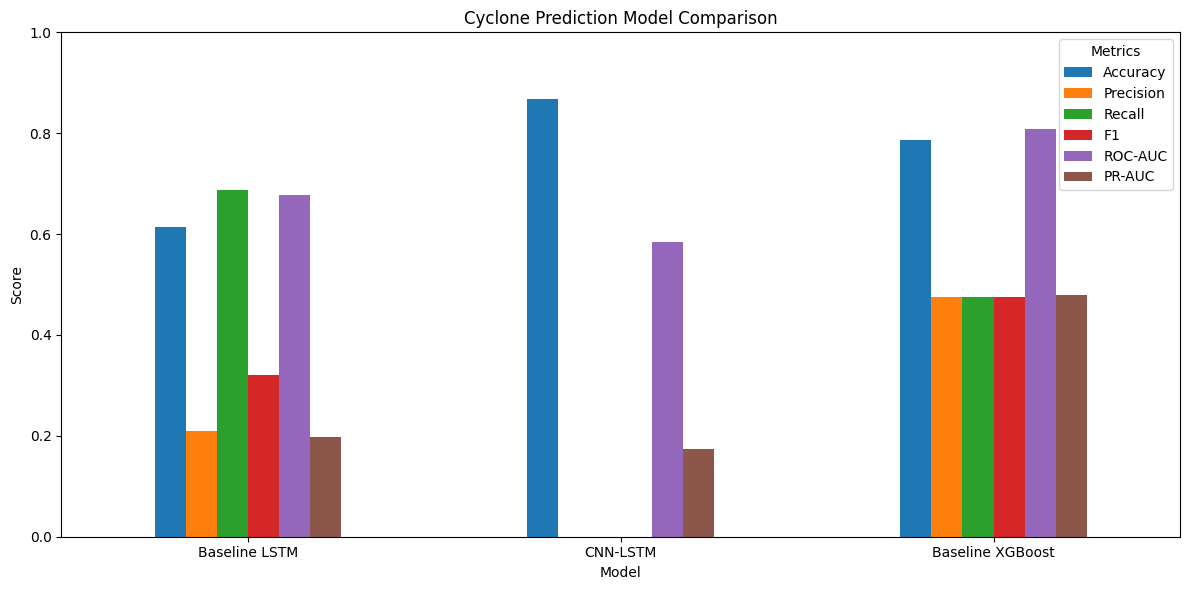

Comparison chart saved successfully.
results/model_comparison_chart.png


In [38]:
# ============================================================
# Model Comparison Chart
# ============================================================

import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

ax = comparison[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cyclone Prediction Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()

plt.savefig(
    "results/model_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Comparison chart saved successfully.")
print("results/model_comparison_chart.png")

In [39]:
# ============================================================
# Save Final Comparison CSV
# ============================================================

comparison.to_csv(
    "results/model_comparison_summary.csv"
)

print("Comparison summary saved successfully.")
print("results/model_comparison_summary.csv")

Comparison summary saved successfully.
results/model_comparison_summary.csv


In [40]:
# ============================================================
# Final Model Summary
# ============================================================

print("=" * 60)
print("CYCLONE PREDICTION - FINAL MODEL SUMMARY")
print("=" * 60)

display(comparison)

print("\nBest models by metric:")

for metric in comparison.columns:
    best_model = comparison[metric].idxmax()
    best_score = comparison.loc[best_model, metric]

    print(
        f"{metric:10s}: "
        f"{best_model:20s} = {best_score:.4f}"
    )

print("\nTraining pipeline completed successfully.")

CYCLONE PREDICTION - FINAL MODEL SUMMARY


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline LSTM,0.6139,0.2091,0.6866,0.3206,0.6780,0.1983
CNN-LSTM,0.8673,0.0000,0.0000,0.0000,0.5842,0.1731
Baseline XGBoost,0.7857,0.4747,0.4747,0.4747,0.8084,0.4800



Best models by metric:
Accuracy  : CNN-LSTM             = 0.8673
Precision : Baseline XGBoost     = 0.4747
Recall    : Baseline LSTM        = 0.6866
F1        : Baseline XGBoost     = 0.4747
ROC-AUC   : Baseline XGBoost     = 0.8084
PR-AUC    : Baseline XGBoost     = 0.4800

Training pipeline completed successfully.
